In [1]:
import json
import math
import os
import gc
import itertools
from functools import partial
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dropout, Flatten, Dense, GlobalAveragePooling2D, Average,
    Input, Concatenate, GlobalMaxPooling2D, BatchNormalization
)
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn import metrics

%matplotlib inline

2026-05-20 17:45:29.504799: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779299129.738858      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779299129.807745      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779299130.369871      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779299130.369908      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779299130.369910      23 computation_placer.cc:177] computation placer alr

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

# Disable XLA
tf.config.optimizer.set_jit(False)

In [3]:
def Dataset_loader_recursive(DIR, RESIZE):
    IMG = []
    
    for root, _, files in os.walk(DIR):
        for file in files:
            PATH = os.path.join(root, file)
            _, ftype = os.path.splitext(PATH)
            
            if ftype.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    img = np.asarray(Image.open(PATH).convert("RGB"))
                    img = cv2.resize(img, (RESIZE, RESIZE))
                    IMG.append(img)
                except:
                    continue
    
    return np.array(IMG)
DIR = "/kaggle/input/datasets/tueoban/aisslab-breast-cancer-sub-datasets/AISSLab Sub-datasets/Augmented Sub-datasets/AISSLab-v5/"

benign_bi_rads_2 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 2"), RESIZE=224)
benign_bi_rads_3 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 3"), RESIZE=224)

malignant_bi_rads_4 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 4"), RESIZE=224)
malignant_bi_rads_5 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 5"), RESIZE=224)

#normal = Dataset_loader_recursive(os.path.join(DIR, "Normal/JPG/"), RESIZE=224)

In [4]:
print("Total images loaded:", len(benign_bi_rads_2))
print("Shape:", benign_bi_rads_2.shape)

print("Total images loaded:", len(benign_bi_rads_3))
print("Shape:", benign_bi_rads_3.shape)

print("Total images loaded:", len(malignant_bi_rads_4))
print("Shape:", malignant_bi_rads_4.shape)

print("Total images loaded:", len(malignant_bi_rads_5))
print("Shape:", malignant_bi_rads_5.shape)

Total images loaded: 72
Shape: (72, 224, 224, 3)
Total images loaded: 192
Shape: (192, 224, 224, 3)
Total images loaded: 224
Shape: (224, 224, 224, 3)
Total images loaded: 176
Shape: (176, 224, 224, 3)


In [5]:
#normal_label = np.full(len(normal),0)
benign_bi_rads_2_label = np.full(len(benign_bi_rads_2), 0)
benign_bi_rads_3_label = np.full(len(benign_bi_rads_3),1)
malignant_bi_rads_4_label = np.full(len(malignant_bi_rads_4),2)
malignant_bi_rads_5_label = np.full(len(malignant_bi_rads_5),3)

In [6]:
X = np.concatenate((benign_bi_rads_2, benign_bi_rads_3, malignant_bi_rads_4, malignant_bi_rads_5), axis = 0)
Y = np.concatenate((benign_bi_rads_2_label, benign_bi_rads_3_label, malignant_bi_rads_4_label, malignant_bi_rads_5_label), axis = 0)

# Shuffle train data
s = np.arange(X.shape[0])
np.random.shuffle(s)
X = X[s]
Y = Y[s]

# DENSENET PREPROCESSING
X = preprocess_input(
    X.astype("float32")
)
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=11,
    stratify=Y
)

In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=11,
    stratify=y_train
)

print("\nFinal Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


Final Shapes:
x_train: (424, 224, 224, 3)
y_train: (424,)
x_val: (107, 224, 224, 3)
y_val: (107,)
x_test: (133, 224, 224, 3)
y_test: (133,)


In [8]:
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.utils import to_categorical
from collections import Counter
import numpy as np

# Convert one-hot -> labels if needed
if len(y_train.shape) > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# Check original distribution
print("Original class distribution:")
print(Counter(y_train_labels))

# Flatten image data temporarily
nsamples, h, w, c = x_train.shape

x_train_flat = x_train.reshape(
    (nsamples, h * w * c)
)

target = 1200

sampling_strategy = {
    0: target,
    1: target,
    2: target,
    3: target
}

# Apply Oversampling
ros = RandomOverSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

x_train, y_train = ros.fit_resample(
    x_train_flat,
    y_train_labels
)

# Restore image shape
x_train = x_train.reshape(
    (-1, h, w, c)
)

# One-hot Encode Labels
y_train = to_categorical(
    y_train,
    num_classes=4
)

# Validation labels
if len(y_val.shape) == 1:
    y_val = to_categorical(y_val, num_classes=4)

# Test labels
if len(y_test.shape) == 1:
    y_test = to_categorical(y_test, num_classes=4)

# Final Distribution
print("\nBalanced class distribution:")
print(Counter(np.argmax(y_train, axis=1)))

Original class distribution:
Counter({np.int64(2): 143, np.int64(1): 122, np.int64(3): 113, np.int64(0): 46})

Balanced class distribution:
Counter({np.int64(1): 1200, np.int64(3): 1200, np.int64(2): 1200, np.int64(0): 1200})


In [9]:
BATCH_SIZE = 32

# Using original generator
train_generator = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

In [10]:
from tensorflow.keras.applications import VGG16, VGG19

In [11]:
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.optimizers import Adam
def build_model(model_name):
    inputs = Input(shape=(224,224,3))

    # SELECT MODEL
    if model_name == "VGG16":

        base_model = VGG16(
            weights='imagenet',
            include_top=False,
            input_tensor=inputs
        )

    elif model_name == "VGG19":

        base_model = VGG19(
            weights='imagenet',
            include_top=False,
            input_tensor=inputs
        )

    # FREEZE LAYERS
    for layer in base_model.layers:
        layer.trainable = False

    # CUSTOM HEAD
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(4, activation='softmax')(x)

    # FINAL MODEL
    model = Model(inputs, outputs)

    # COMPILE
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

In [12]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

def get_callbacks(model_name):

    checkpoint = ModelCheckpoint(
        f"/kaggle/working/{model_name}_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    earlystop = EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        mode='max',
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    return [checkpoint, earlystop, reduce_lr]

In [13]:
def train_model(model, model_name):
    history = model.fit(
        train_generator.flow(
            x_train,
            y_train,
            batch_size=32
        ),
        steps_per_epoch=x_train.shape[0] // 32,
        validation_data=(x_val, y_val),
        epochs=30,
        callbacks=get_callbacks(model_name)
    )
    return history

In [14]:
def fine_tune_model(model, base_model, model_name):

    # Unfreeze last 4 layers
    for layer in base_model.layers[-4:]:
        layer.trainable = True

    # Recompile
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_fine = model.fit(
        train_generator.flow(
            x_train,
            y_train,
            batch_size=32
        ),
        steps_per_epoch=x_train.shape[0] // 32,
        validation_data=(x_val, y_val),
        epochs=30,
        callbacks=get_callbacks(model_name)
    )

    return history_fine

In [15]:
# BUILD MODEL
model_vgg16, base_vgg16 = build_model("VGG16")

# TRAIN
history_vgg16 = train_model(model_vgg16,"VGG16")

# FINE TUNE
history_vgg16_fine = fine_tune_model(model_vgg16,base_vgg16,"VGG16")

I0000 00:00:1779299216.973433      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779299216.979658      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1779299222.006474      73 service.cc:152] XLA service 0x7dec0c006950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779299222.006536      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779299222.006543      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779299222.690444      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/150 ━━━━━━━━━━━━━━━━━━━━ 41:16 17s/step - accuracy: 0.2188 - loss: 2.3685

I0000 00:00:1779299236.213497      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.2821 - loss: 2.0673
Epoch 1: val_accuracy improved from -inf to 0.42056, saving model to /kaggle/working/VGG16_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 373ms/step - accuracy: 0.2822 - loss: 2.0667 - val_accuracy: 0.4206 - val_loss: 1.3560 - learning_rate: 1.0000e-04
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.3606 - loss: 1.7541
Epoch 2: val_accuracy improved from 0.42056 to 0.44860, saving model to /kaggle/working/VGG16_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 50s 333ms/step - accuracy: 0.3607 - loss: 1.7537 - val_accuracy: 0.4486 - val_loss: 1.2692 - learning_rate: 1.0000e-04
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.4161 - loss: 1.5508
Epoch 3: val_accuracy improved from 0.44860 to 0.48598, saving model to /kaggle/working/VGG16_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 50s 332ms/step - accuracy: 0.4161 - loss: 1.5505 - val_accuracy: 0.4860 - val_loss: 1.1979 - learning_rate: 1.

In [16]:
pred_vgg16 = model_vgg16.predict(x_test)
y_pred_vgg16 = np.argmax(pred_vgg16, axis=1)
y_true = np.argmax(y_test, axis=1)

from sklearn.metrics import accuracy_score

acc_vgg16 = accuracy_score(y_true,y_pred_vgg16)
print("VGG16 Accuracy:", acc_vgg16)

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
VGG16 Accuracy: 0.9699248120300752


In [17]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()

gc.collect()

0

In [18]:
# BUILD MODEL
model_vgg19, base_vgg19 = build_model("VGG19")

# TRAIN
history_vgg19 = train_model(model_vgg19,"VGG19")

# FINE TUNE
history_vgg19_fine = fine_tune_model(model_vgg19,base_vgg19,"VGG19")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.2791 - loss: 2.1737
Epoch 1: val_accuracy improved from -inf to 0.26168, saving model to /kaggle/working/VGG19_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 63s 389ms/step - accuracy: 0.2793 - loss: 2.1729 - val_accuracy: 0.2617 - val_loss: 1.6635 - learning_rate: 1.0000e-04
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.3669 - loss: 1.7876
Epoch 2: val_accuracy improved from 0.26168 to 0.33645, saving model to /kaggle/working/VGG19_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 57s 380ms/step - accuracy: 0.3669 - loss: 1.7873 - val_accuracy: 0.3364 - val_loss: 1.5885 - learning_rate: 1.0000e-04
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.4070 - loss: 1.5955
Epoch 3: val_accuracy improved from 0.33645 to 0.38318, saving model to /kaggle/working/VGG19_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 56s 370ms/step - accuracy: 0.4070 - loss: 1.5953 - val_accuracy: 0.3832 - val_loss: 1.5272 - learni

In [19]:
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef,mean_absolute_error,mean_squared_error,cohen_kappa_score)
import itertools
def evaluate_model(model, model_name):

    print(f"\n{'='*50}")
    print(f"{model_name} EVALUATION")
    print(f"{'='*50}")

    # Prediction
    pred = model.predict(x_test)
    y_pred = np.argmax(pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true,y_pred,average='weighted')
    recall = recall_score(y_true,y_pred,average='weighted')

    f1 = f1_score(y_true,y_pred,average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred )
    kappa = cohen_kappa_score(y_true,y_pred )

    # Classification Report
    print("\nClassification Report:\n")

    target_names = ['Benign (BI-RADS 2)','Benign (BI-RADS 3)','Malign (BI-RADS 4)','Malign (BI-RADS 5)']
    print(classification_report(y_true,y_pred,target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:\n")
    print(cm)
    # Plot CM
    plt.figure(figsize=(6,6))
    plt.imshow(cm, cmap=plt.cm.Blues)
    plt.title(f'{model_name} Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks,target_names,rotation=45)
    plt.yticks(tick_marks,target_names)
    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,
            format(cm[i, j], 'd'),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    # Final Metrics
    print("\nAdditional Metrics:\n")
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-score       : {f1:.4f}")
    print(f"MCC            : {mcc:.4f}")
    print(f"Cohen Kappa    : {kappa:.4f}")
    return accuracy


VGG16 EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step

Classification Report:

                    precision    recall  f1-score   support

Benign (BI-RADS 2)       1.00      0.93      0.96        14
Benign (BI-RADS 3)       0.93      1.00      0.96        39
Malign (BI-RADS 4)       1.00      0.93      0.97        45
Malign (BI-RADS 5)       0.97      1.00      0.99        35

          accuracy                           0.97       133
         macro avg       0.98      0.97      0.97       133
      weighted avg       0.97      0.97      0.97       133


Confusion Matrix:

[[13  1  0  0]
 [ 0 39  0  0]
 [ 0  2 42  1]
 [ 0  0  0 35]]


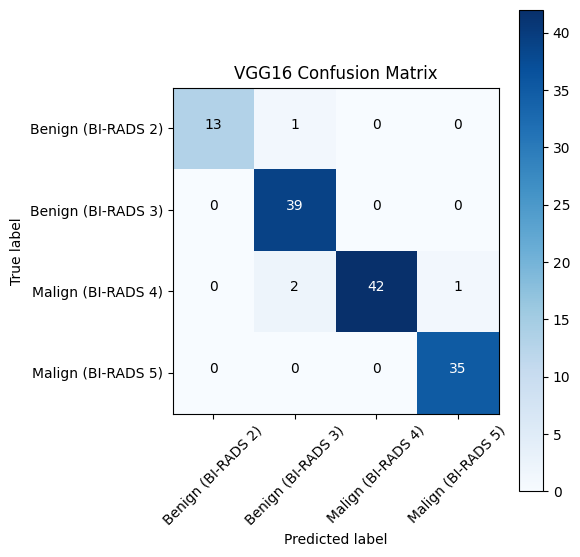


Additional Metrics:

Accuracy       : 0.9699
Precision      : 0.9717
Recall         : 0.9699
F1-score       : 0.9699
MCC            : 0.9589
Cohen Kappa    : 0.9582


In [20]:
acc_vgg16 = evaluate_model(
    model_vgg16,
    "VGG16"
)


VGG19 EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 405ms/step

Classification Report:

                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.81      0.93      0.87        14
Benign (BI-RADS 3)       0.95      0.97      0.96        39
Malign (BI-RADS 4)       1.00      0.93      0.97        45
Malign (BI-RADS 5)       0.97      0.97      0.97        35

          accuracy                           0.95       133
         macro avg       0.93      0.95      0.94       133
      weighted avg       0.96      0.95      0.96       133


Confusion Matrix:

[[13  1  0  0]
 [ 1 38  0  0]
 [ 1  1 42  1]
 [ 1  0  0 34]]


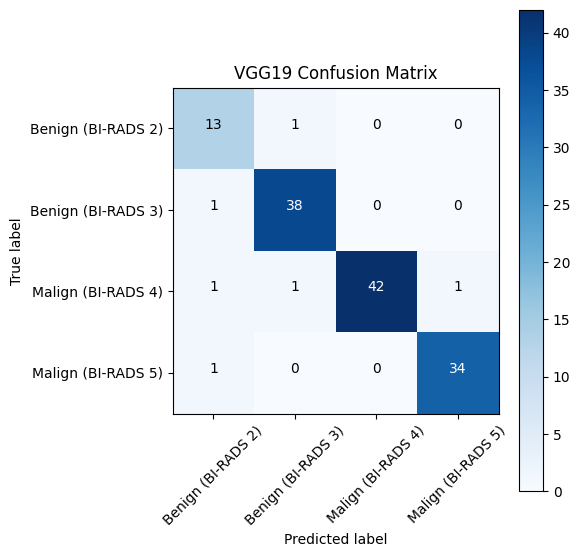


Additional Metrics:

Accuracy       : 0.9549
Precision      : 0.9581
Recall         : 0.9549
F1-score       : 0.9556
MCC            : 0.9381
Cohen Kappa    : 0.9376


In [21]:
acc_vgg19 = evaluate_model(
    model_vgg19,
    "VGG19"
)

In [22]:
print("\nFINAL COMPARISON")
print("="*40)

print(f"VGG16 Accuracy : {acc_vgg16:.4f}")

print(f"VGG19 Accuracy : {acc_vgg19:.4f}")

if acc_vgg16 > acc_vgg19:

    print("\nBest Model : VGG16")

else:

    print("\nBest Model : VGG19")


FINAL COMPARISON
VGG16 Accuracy : 0.9699
VGG19 Accuracy : 0.9549

Best Model : VGG16
